In [2]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import export_text
from sklearn.preprocessing import MinMaxScaler

In [9]:
# Read in Data from CSV
raw_data = np.genfromtxt("/home/vivaan/Documents/Code/Projects/Bionic-Hand-Scripts/data/Spring 2026/lk_pressed_highpos.csv", delimiter=',')
# Convert Integer Time to Float ime
# Since we will have several readings with the same time in the csv, 
# we have to split these up by millisecond intervals
# If we have five readings at 67 seconds, we will split them up into 5 time slots
# 67.0, 67.2, 67.4, 67.6, 67.8


running_list_x = []
running_list_y = []
# Final values to be stored in the DataFrame
final_x = []
final_y = []

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

print(raw_data)

prev = 0
total = 0
for x,y in raw_data:
    
    final_x.append(x)
    final_y.append(y)
    


# Normalize the final_y values
final_x = np.array(final_x).reshape(-1, 1)  # Reshape to 2D
final_x = scaler.fit_transform(final_x).flatten()  # Flatten back to 1D
final_y = np.array(final_y)*1e-6

[[2.7000000e+01 3.8800000e+02]
 [2.7000000e+01 1.0788000e+04]
 [2.7000000e+01 2.1276000e+04]
 ...
 [9.3300000e+02 1.3806528e+08]
 [9.3300000e+02 1.3807600e+08]
 [9.3300000e+02 1.3808672e+08]]


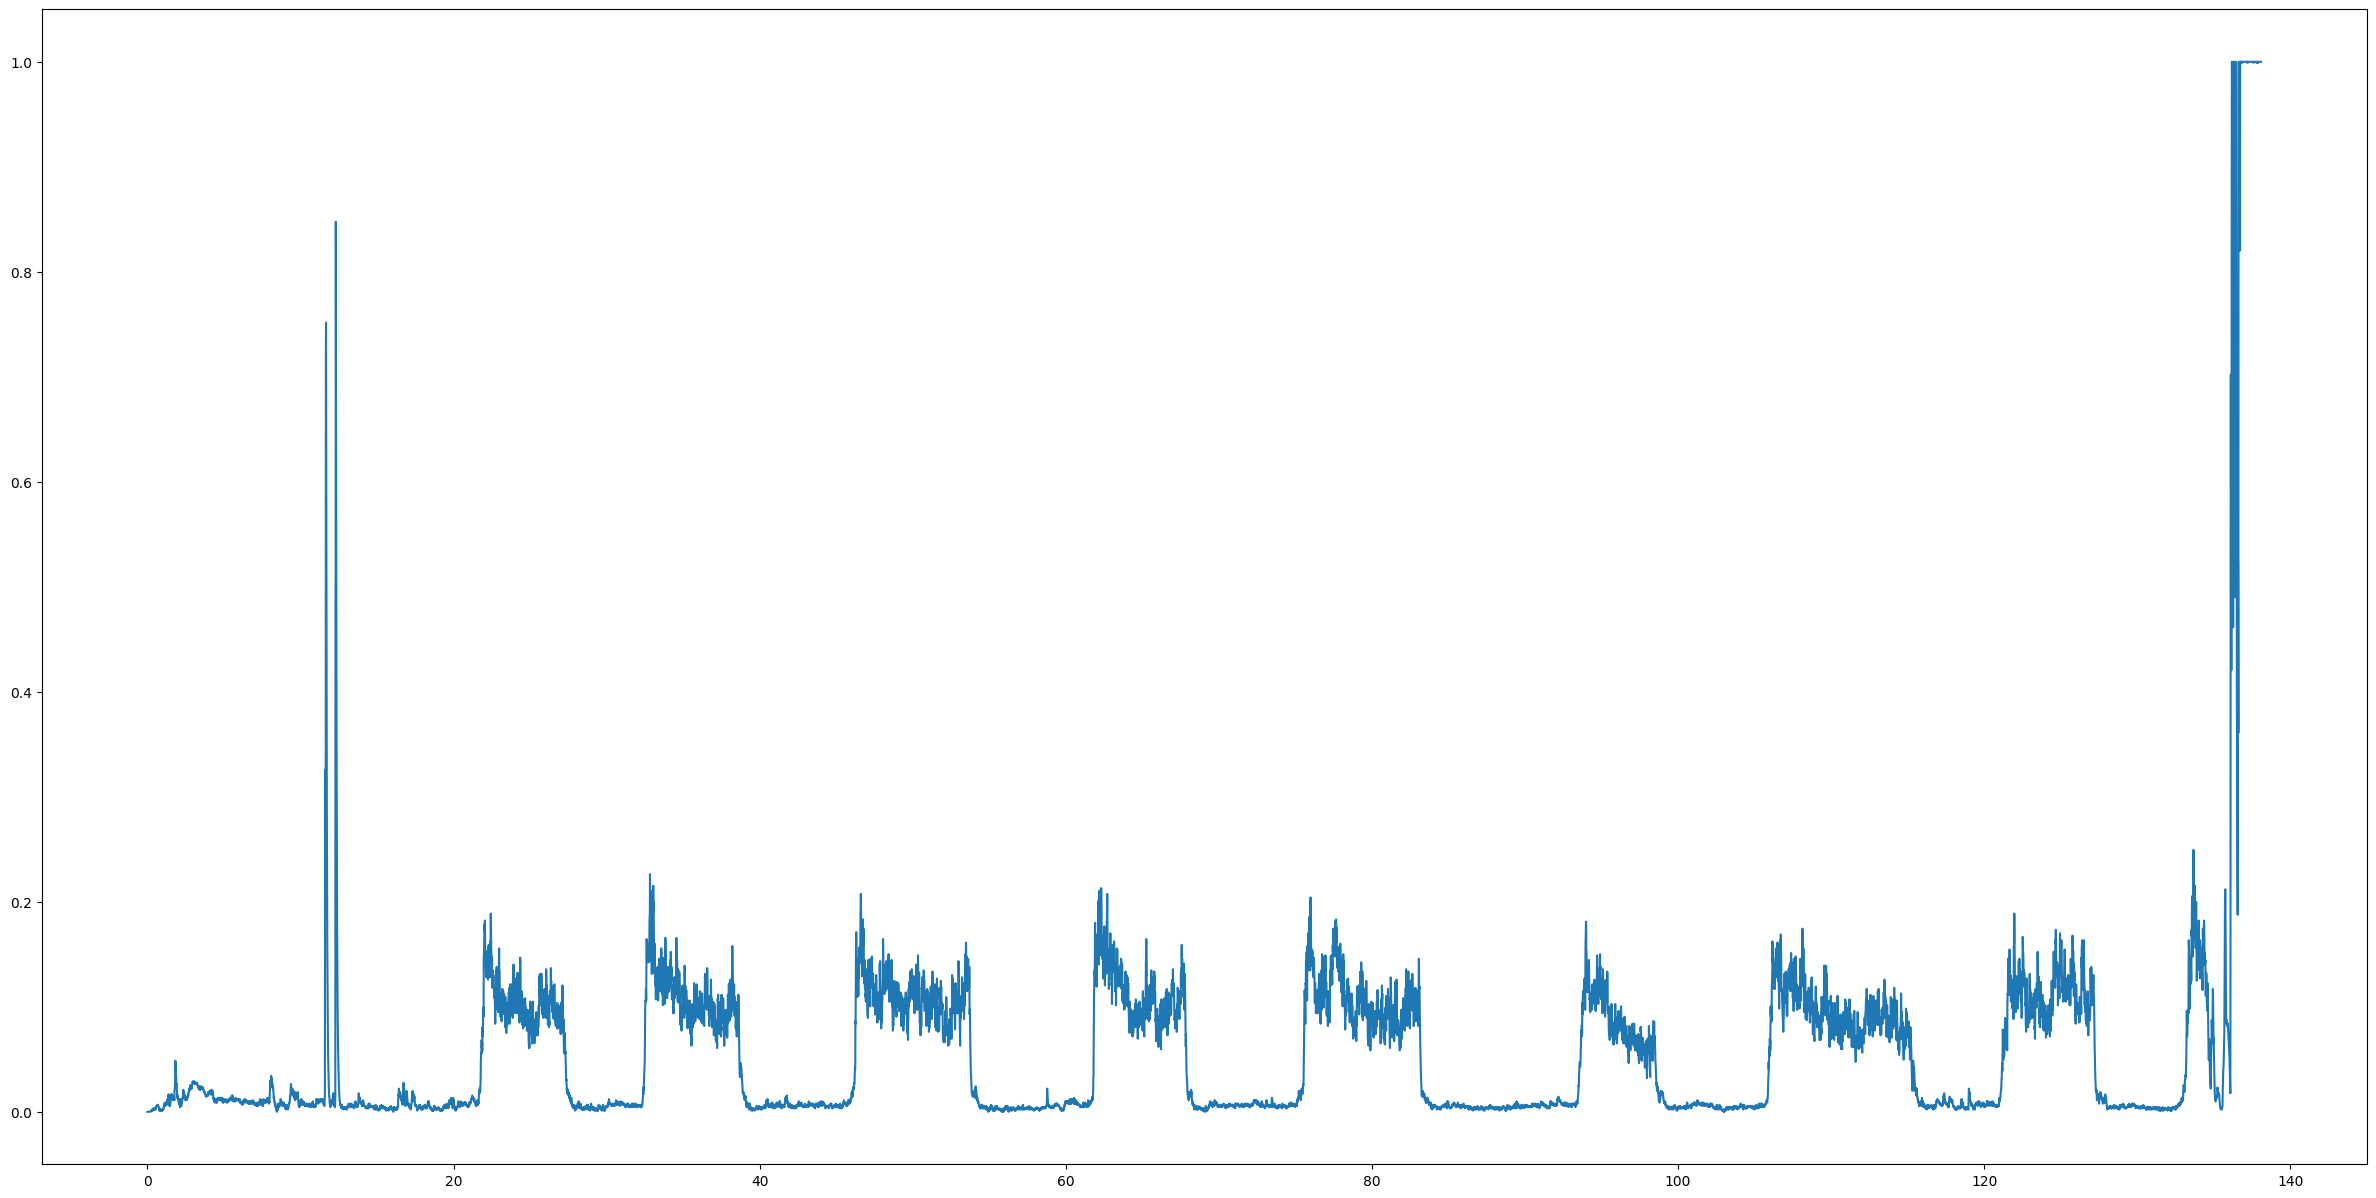

,Time,Signal
0,0.000000,0.0
1,0.010488,0.0
2,0.020988,0.0
3,0.031480,0.0
4,0.041968,0.0


12966


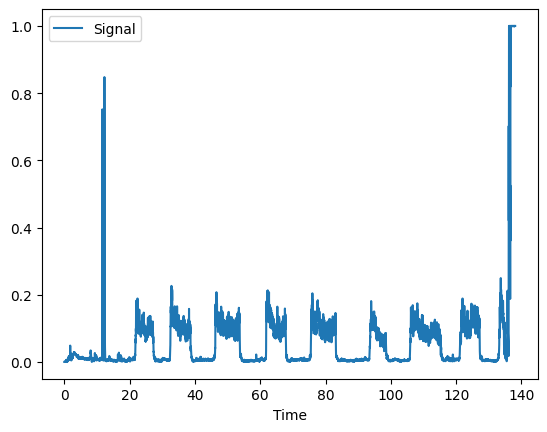

In [18]:
# Initial Plot
plt.figure(figsize=(30, 15))
plt.plot(final_y, final_x)
plt.show()

# Create a Pandas DataFrame
orignal = pd.DataFrame({"Time": final_y[1:], "Signal": final_x[1:]})

# Filter out data before the start time
#df = orignal[orignal["Time"] > ].copy()
df = orignal.copy()

#Standardize time so the first point is at 0 seconds
df["Time"] = df["Time"] - min(df["Time"])

# Print
display(df.head())
print(len(df))

#df = df[df["Time"] < 80000000].copy()

# Final Plot
plot = df.plot(x="Time",y='Signal')
plt.show()

In [16]:
#Known open and closed intervals
interval_times_1 = [5.15, 4.53, 5.35, 5.25, 4.73, 5.03, 5.31, 4.38, 5.15, 5.31, 4.70, 4.75]

interval_times_2 = [10.08, 5.33, 5.20, 6.76, 6.91, 7.86, 7.63, 6.43, 7.26, 8.45, 10.00, 5.10, 7.33, 9.26, 5.73, 6.05, 5.46]

interval_times_3 = [7.03, 10.06, 8.03, 10.33, 4.86, 6.01, 7.93, 10.08, 9.58, 5,11, 6.35, 9.56, 5.43, 6.73, 5.30, 7.88, 1.08]

11.7
21.78
21.78
27.11
27.11
32.31
32.31
39.07
39.07
45.980000000000004
45.980000000000004
53.84
53.84
61.470000000000006
61.470000000000006
67.9
67.9
75.16000000000001
75.16000000000001
83.61000000000001
83.61000000000001
93.61000000000001
93.61000000000001
98.71000000000001
98.71000000000001
106.04
106.04
115.30000000000001
115.30000000000001
121.03000000000002
121.03000000000002
127.08000000000001
127.08000000000001
132.54000000000002


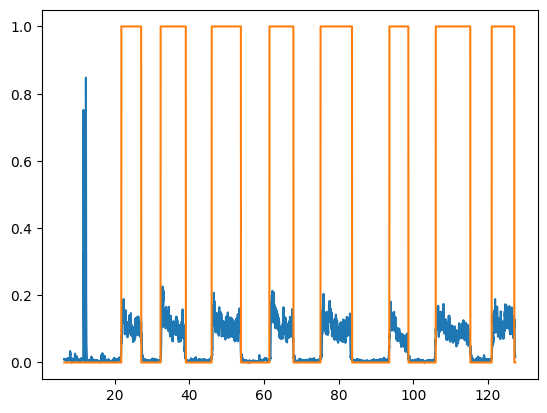

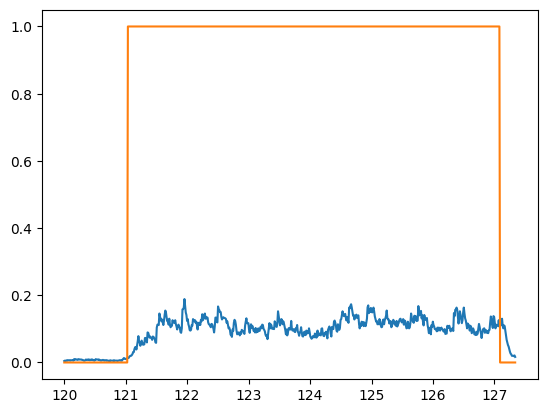

             Time    Signal  State
11275  120.001968  0.004415    0.0
11276  120.012640  0.005519    0.0
11277  120.023304  0.004415    0.0
11278  120.033976  0.005519    0.0
11279  120.044640  0.006623    0.0
...           ...       ...    ...
11956  127.293768  0.019868    0.0
11957  127.304440  0.019868    0.0
11958  127.315104  0.018764    0.0
11959  127.325776  0.020971    0.0
11960  127.336440  0.016556    0.0

[686 rows x 3 columns]


In [28]:
# Throw out data before here
interval_times = interval_times_2

start_time = 11.7

# Label each point with a State based on the interval
for i in range(len(interval_times)):
    print(start_time)
    end_time = start_time + interval_times[i]
    print(end_time)
    df.loc[df["Time"].between(start_time, end_time), "State"] = i%2
            
    start_time = end_time
    
# Plot Data
plt.plot(df["Time"], df["Signal"])
plt.plot(df["Time"], df["State"])

# Removes any numbers which are infinity or NaN
df = df[df["State"].apply(lambda x: not (pd.isna(x) or x in [float('inf'), float('-inf')]))]

plt.show()

df_section = df[df['Time'].between(120, 130)].copy()
plt.plot(df_section["Time"], df_section["Signal"])
plt.plot(df_section["Time"], df_section["State"])
plt.show()

print(df[df['Time'].between(120, 130)])